# Математические методы анализа данных

## Семинар 3: Градиентный спуск, Линейная регрессия

На этом семинаре мы обсудим градиентный спуск, его модификации и подбор их параметров.

В ноутбуке используется библиотека `plotly` для создания интерактивных графиков. Такие графики не отображаются в `nbviewer` и на GitHub. Чтобы их посмотреть, скачайте ноутбук, откройте его локально и выполните ячейки заново.

## Градиентный спуск

Напомним, что при градиентном спуске новые значения параметров получают из предыдущих, делая шаг в направлении антиградиента функции потерь:

$$w^{(t)} = w^{(t-1)} - \eta_t \nabla Q(w^{(t-1)}),$$
$\eta_t$ — скорость обучения.

### Асимптотическая вычислительная сложность

Оптимальные веса линейной регрессии с точки зрения MSE имеют вид $w = (X^TX)^{-1}X^Ty$. В этой формуле нужно обратить матрицу $X^TX$, что при большом числе признаков требует много вычислений. Сложность составляет $O(d^3 + d^2\ell)$. В реальных задачах такие затраты часто неприемлемы, поэтому параметры ищут итеративными методами. Один из них — градиентный спуск.

Градиент MSE записывается так:

$$\nabla Q(w) = 2X^T(Xw - y).$$

Сложность вычислений в этом случае — $O(d\ell)$. При стохастическом градиентном спуске вместо полного градиента используют его несмещённую оценку по одному или нескольким объектам. Тогда сложность составляет $O(kd)$, где $k$ — число объектов, по которым оценивают градиент, причём $k \ll \ell$. Это отчасти объясняет популярность стохастических методов оптимизации.

### Визуализация траекторий GD и SGD

Сгенерируем матрицу «объекты — признаки» $X$ и вектор истинных весов $w_{true}$, вычислим целевую переменную $y = Xw_{true}$ и добавим нормальный шум:

In [1]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
n_features = 2
n_objects = 300

np.random.seed(100)
w_true = np.random.normal(size=(n_features, ))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]  # for different scales

Y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))

w_0 = np.random.uniform(-1, 1, (n_features))

Зададим параметры градиентного спуска:

In [3]:
batch_size = 10
num_steps = 50

Обучим линейную регрессию на полученных данных, минимизируя MSE полным градиентным спуском. В результате получим вектор параметров.

In [4]:
step_size = 1e-2

w = w_0.copy()
w_list = [w.copy()]

for i in range(num_steps):
    w -= 2 * step_size * np.dot(X.T, np.dot(X, w) - Y) / Y.shape[0]
    w_list.append(w.copy())

w_list = np.array(w_list)

In [5]:
import plotly.graph_objects as go


def compute_limits(w_list):
    dx = np.max(np.abs(w_list[:, 0] - w_true[0])) * 1.1
    dy = np.max(np.abs(w_list[:, 1] - w_true[1])) * 1.1

    return (w_true[0] - dx, w_true[0] + dx), (w_true[1] - dy, w_true[1] + dy)


def compute_levels(w_list, x_range, y_range, num: int = 100):
    x, y = np.linspace(x_range[0], x_range[1], num), np.linspace(y_range[0], y_range[1], num)
    A, B = np.meshgrid(x, y)

    levels = np.empty_like(A)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = np.mean(np.power(np.dot(X, w_tmp) - Y, 2))

    return x, y, levels


def make_contour(x, y, levels, name: str=None):
    return go.Contour(
        x=x,
        y=y,
        z=levels,
        contours_coloring='lines',
        line_smoothing=1,
        line_width=2,
        ncontours=100,
        opacity=0.5,
        name=name
    )


def make_arrow(figure, x, y):
    x, dx = x
    y, dy = y

    figure.add_annotation(
        x=x,
        y=y,
        ax=x + dx,
        ay=y + dy,
        xref='x',
        yref='y',
        text='',
        showarrow=True,
        axref = 'x',
        ayref='y',
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
    )


def plot_trajectory(w_list, name):
    # compute limits
    x_range, y_range = compute_limits(w_list)

    # compute level set
    x, y, levels = compute_levels(w_list, x_range, y_range)

    # plot levels
    contour = make_contour(x, y, levels, 'Loss function levels')

    # plot weights
    w_path = go.Scatter(
        x=w_list[:, 0][:-1],
        y=w_list[:, 1][:-1],
        mode='lines+markers',
        name='W',
        marker=dict(size=7, color='red')
    )

    # plot final weight
    w_final = go.Scatter(
        x=[w_list[:, 0][-1]],
        y=[w_list[:, 1][-1]],
        mode='markers',
        name='W_final',
        marker=dict(size=10, color='black'),
    )

    # plot true optimum
    w_true_point = go.Scatter(
        x=[w_true[0]],
        y=[w_true[1]],
        mode='markers',
        name='W_true',
        marker=dict(size=10, color='black'),
        marker_symbol='star'
    )

    # make the figure
    fig = go.Figure(data=[contour, w_path, w_final, w_true_point])

    fig.update_xaxes(type='linear', range=x_range)
    fig.update_yaxes(type='linear', range=y_range)

    fig.update_layout(title=name)

    fig.update_layout(
        autosize=True,
        width=700,
        margin=dict(
            l=50,
            r=50,
            b=50,
            t=100,
            pad=4
        ),
        paper_bgcolor='LightSteelBlue',
    )

    fig.update_layout(legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ))

    fig.update_traces(showlegend=True)

    fig.show()

In [6]:
plot_trajectory(w_list, 'Gradient descent')

Из математического анализа известно, что градиент перпендикулярен линиям уровня. Чтобы лучше понять траектории градиентного спуска, вычислим градиент функции в разных точках пространства и покажем его направление.

In [7]:
# make new figure with contour lines
x_range, y_range = compute_limits(w_list)
x, y, levels = compute_levels(w_list, x_range, y_range)
contour = make_contour(x, y, levels, 'Loss function levels')
fig = go.Figure(data=[contour])

# visualize the gradients

x_smol, y_smol, _ = compute_levels(w_list, x_range, y_range, num=10)
x_smol, y_smol = x_smol[1:-1], y_smol[1:-1]
A_smol, B_smol = np.meshgrid(x_smol, y_smol)

for i in range(A_smol.shape[0]):
    for j in range(A_smol.shape[1]):
        w_tmp = np.array([A_smol[i, j], B_smol[i, j]])

        antigrad = 0.003 * np.dot(X.T, np.dot(X, w_tmp) - Y) / Y.shape[0]

        make_arrow(fig, (A_smol[i, j], antigrad[0]), (B_smol[i, j], antigrad[1]))


fig.update_xaxes(type='linear', range=x_range)
fig.update_yaxes(type='linear', range=y_range)

fig.update_layout(title = 'Antigradient')

fig.update_layout(
    autosize=True,
    width=700,
    margin=dict(
        l=50,
        r=50,
        b=50,
        t=100,
        pad=4
    ),
    paper_bgcolor='LightSteelBlue',
)

fig.show()

Теперь визуализируем траектории стохастического градиентного спуска. Повторим те же шаги, но будем оценивать градиент по подвыборке данных.

In [8]:
def calc_grad_on_batch(X, Y, w, batch_size):
    sample = np.random.randint(n_objects, size=batch_size)
    return 2 * np.dot(X[sample].T, np.dot(X[sample], w) - Y[sample]) / batch_size

In [9]:
step_size = 1e-2

w = w_0.copy()
w_list = [w.copy()]

for i in range(num_steps):
    w -= step_size * calc_grad_on_batch(X, Y, w, batch_size)
    w_list.append(w.copy())

w_list = np.array(w_list)

In [10]:
plot_trajectory(w_list, 'Stochastic gradient descent')

Как видно, стохастический градиентный спуск «блуждает» вокруг оптимума. Это связано с выбором шага $\eta_k$. Для сходимости метода последовательность шагов должна удовлетворять [условиям Роббинса — Монро](https://projecteuclid.org/download/pdf_1/euclid.aoms/1177729586):

$$
\sum_{k = 1}^\infty \eta_k = \infty, \qquad \sum_{k = 1}^\infty \eta_k^2 < \infty.
$$

Интуитивно первое условие позволяет методу пройти сколь угодно большое расстояние, а второе требует, чтобы шаги достаточно быстро уменьшались.

Посмотрим на траектории SGD при последовательности шагов, удовлетворяющей условиям Роббинса — Монро:

In [11]:
step_size_0 = 0.01

w = w_0.copy()
w_list = [w.copy()]


for i in range(num_steps):
    step_size = step_size_0 / (i+1)
    w -= step_size * calc_grad_on_batch(X, Y, w, batch_size)
    w_list.append(w.copy())

w_list = np.array(w_list)

In [12]:
plot_trajectory(w_list, 'Stochastic gradient descent with dynamic learning rate')

Теперь градиентный спуск движется более направленно, но не достигает оптимума. Попробуем более сложную схему изменения длины шага:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p.
$$

Положим $s_0 = 1$ и попробуем разные значения $\lambda$ и $p$.

In [13]:
def sgd_with_lr_schedule(lambda_param, p=0.5, s_init=1.0, batch_size=10):
    w = w_0.copy()
    w_list = [w.copy()]


    for i in range(num_steps):
        step_size = lambda_param * np.power(s_init / (s_init + i), p)
        w -= step_size * calc_grad_on_batch(X, Y, w, batch_size)
        w_list.append(w.copy())

    return np.array(w_list)

In [14]:
w_list = sgd_with_lr_schedule(lambda_param=0.01, p=0.8)
plot_trajectory(w_list, 'SGD with learning rate schedule')

In [15]:
w_list = sgd_with_lr_schedule(lambda_param=0.01, p=0.5)
plot_trajectory(w_list, 'SGD with learning rate schedule')

In [16]:
w_list = sgd_with_lr_schedule(lambda_param=0.01, p=0.35)
plot_trajectory(w_list, 'SGD with learning rate schedule')

Коэффициенты в формуле длины шага — гиперпараметры, которые нужно подбирать. Для этого целесообразно использовать валидационную выборку.

Посмотрим, как размер подвыборки для оценки градиента влияет на сходимость.

In [17]:
w_list = sgd_with_lr_schedule(lambda_param=0.01, p=0.35, batch_size=1)
plot_trajectory(w_list, 'SGD with learning rate schedule')

In [18]:
w_list = sgd_with_lr_schedule(lambda_param=0.01, p=0.35, batch_size=10)
plot_trajectory(w_list, 'SGD with learning rate schedule')

In [19]:
w_list = sgd_with_lr_schedule(lambda_param=0.01, p=0.35, batch_size=100)
plot_trajectory(w_list, 'SGD with learning rate schedule')

В целом вывод ожидаемый: чем больше подвыборка, тем стабильнее траектория градиентного спуска. Интереснее посмотреть, как её размер влияет на скорость сходимости.

### Сравнение скоростей сходимости

Исследуем, как быстро полный и стохастический градиентный спуск приближаются к оптимуму. Сгенерируем выборку и построим график зависимости значения функции потерь от номера итерации.

In [20]:
num_steps = 100
batch_size = 10

In [21]:
# data generation
n_features = 50
n_objects = 10000

w_true = np.random.uniform(-2, 2, n_features)

X = np.random.uniform(-10, 10, (n_objects, n_features))
Y = X.dot(w_true) + np.random.normal(0, 5, n_objects)

In [22]:
from scipy.linalg import norm

step_size_sgd = 1e-2
step_size_gd = 1e-2

w_sgd = np.random.uniform(-1, 1, n_features)
w_gd = w_sgd.copy()

residuals_sgd = [np.mean(np.power(np.dot(X, w_sgd) - Y, 2))]
residuals_gd = [np.mean(np.power(np.dot(X, w_gd) - Y, 2))]

norm_sgd = []
norm_gd = []


for i in range(num_steps):
    step_size = step_size_sgd / ((i+1) ** 0.4)
    sample = np.random.randint(n_objects, size=batch_size)

    w_sgd -= step_size * calc_grad_on_batch(X, Y, w_sgd, batch_size)
    residuals_sgd.append(np.mean(np.power(np.dot(X, w_sgd) - Y, 2)))
    norm_sgd.append(norm(np.dot(X[sample].T, np.dot(X[sample], w_sgd) - Y[sample])))

    w_gd -= 2 * step_size_gd * np.dot(X.T, np.dot(X, w_gd) - Y) / Y.shape[0]
    residuals_gd.append(np.mean(np.power(np.dot(X, w_gd) - Y, 2)))
    norm_gd.append(norm(np.dot(X.T, np.dot(X, w_gd) - Y)))

In [23]:
full_gd = go.Scatter(x=np.arange(num_steps+1), y=residuals_gd, name='Full GD')
sgd = go.Scatter(x=np.arange(num_steps+1), y=residuals_sgd, name='SGD')

fig = go.Figure(data=[full_gd, sgd])

fig.update_xaxes(type='linear', range=[-1, num_steps + 1])
fig.update_yaxes(type='linear')

fig.update_layout(title = 'Residuals comparison', xaxis=dict(title="Iteration"))

fig.update_layout(
    autosize=True,
    width=700,
    margin=dict(
        l=50,
        r=50,
        b=50,
        t=100,
        pad=4
    ),
    paper_bgcolor='LightSteelBlue',
)

fig.show()

In [24]:
full_gd = go.Scatter(x=np.arange(num_steps+1), y=norm_gd, name='Full GD')
sgd = go.Scatter(x=np.arange(num_steps+1), y=norm_sgd, name='SGD')

fig = go.Figure(data=[full_gd, sgd])

fig.update_xaxes(type='linear', range=[-1, num_steps + 1])
fig.update_yaxes(type='linear')

fig.update_layout(title = 'Gradient norm comparison', xaxis=dict(title="Iteration"))

fig.update_layout(
    autosize=True,
    width=700,
    margin=dict(
        l=50,
        r=50,
        b=50,
        t=100,
        pad=4
    ),
    paper_bgcolor='LightSteelBlue',
)

fig.show()

Как видно, GD приближается к оптимуму за несколько итераций, а поведение SGD может быть очень нестабильным. Для более сложных моделей при стохастической оптимизации колебания значения функции потерь от итерации к итерации обычно ещё сильнее. Подбором размера шага можно ускорить сходимость; существуют и методы, которые адаптивно выбирают шаг (AdaGrad, Adam, RMSProp).

Также интересно выяснить, насколько мини-пакетный градиентный спуск ускоряет сходимость. Посчитаем, за сколько шагов SGD приближается к истинному решению при разных размерах пакета.

In [25]:
step_size_sgd = 1e-2
step_size_gd = 1e-2
num_steps = 500

w_init = np.random.uniform(-1, 1, n_features)
w_gd = w_init.copy()

for i in range(num_steps):
    w_gd -= 2 * step_size_gd * np.dot(X.T, np.dot(X, w_gd) - Y) / Y.shape[0]

best_error = np.mean(np.power(np.dot(X, w_gd) - Y, 2))
steps_before_conv = []
batch_sizes = np.arange(0, 500, 10)

for batch_size in batch_sizes:
    w_sgd = w_init.copy()
    for i in range(num_steps):
        step_size = step_size_sgd / ((i+1) ** 0.4)
        sample = np.random.randint(n_objects, size=batch_size)

        w_sgd -= step_size * calc_grad_on_batch(X, Y, w_sgd, batch_size)
        err = np.mean(np.power(np.dot(X, w_sgd) - Y, 2))
        if np.abs(err - best_error) < 1:
            break

    steps_before_conv.append(i)

In [26]:
conv_speed = go.Scatter(x=batch_sizes, y=steps_before_conv, name='Number of steps to convergence')

fig = go.Figure(data=conv_speed)

fig.update_layout(title='Convergence speed',
                 xaxis=dict(title="batch size"),
                yaxis=dict(title="steps before convergence")
)

fig.update_layout(
    autosize=True,
    width=700,
    margin=dict(
        l=50,
        r=50,
        b=50,
        t=100,
        pad=4
    ),
    paper_bgcolor='LightSteelBlue',
)

fig.show()

На этих данных увеличение размера пакета примерно до 100 заметно ускоряет сходимость по числу шагов. При этом увеличение пакета в 100 раз примерно во столько же раз замедляет каждый шаг градиентного спуска. Поэтому обычно имеет смысл оценивать градиент по небольшой подвыборке.

In [27]:
!pip install numdifftools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 1.8 MB/s eta 0:00:00


In [28]:
import numdifftools as nd

def calc_grad(x, y):

    z = lambda xy: np.sin(0.5*xy[0]**2-0.25*xy[1]**2-1)*np.cos(2*xy[0] + 1 - np.exp(xy[1]))*xy[0]
    dz = nd.Gradient(z)
    dz_dx, dz_dy = dz([x, y])
    return [dz_dx, dz_dy]


def f(x,y):
    return np.sin(0.5*x**2-0.25*y**2-1)*np.cos(2*x + 1 - np.exp(y))*x


def calc_gd_trajectory(x_init = 1.17, y_init = -1.73, alpha = 0.1, n_steps = 100):

    gd_trajectory_x = [x_init]
    gd_trajectory_y = [y_init]
    gd_trajectory_z = [f(x_init, y_init)+0.1]
    gd_steps =['Initial point']

    for i in range(n_steps):
        grad_val = calc_grad(gd_trajectory_x[-1], gd_trajectory_y[-1])
        gd_trajectory_x.append(gd_trajectory_x[-1] - alpha*grad_val[0])
        gd_trajectory_y.append(gd_trajectory_y[-1] - alpha*grad_val[1])
        gd_trajectory_z.append(f(gd_trajectory_x[-1]
                                               , gd_trajectory_y[-1])+0.1)

        gd_steps.append(str(i) + ' step')

    return gd_trajectory_x, gd_trajectory_y, gd_trajectory_z, gd_steps

In [29]:
# alpha should not be greater than 0.5

gd_trajectory_x, gd_trajectory_y, gd_trajectory_z, gd_steps = calc_gd_trajectory(x_init=2.54
                                                                                 , y_init=-1.25
                                                                                 ,alpha=0.2
                                                                                 ,n_steps=100)
x_grid = np.linspace(-4, 4, 100)
y_grid = np.linspace(-4, 4, 100)

X, Y = np.meshgrid(x_grid, y_grid)

Z = (np.sin(0.5*X**2 - 0.25*Y**2-1)*np.cos(2*X + 1 - np.exp(Y)))*X

fig = go.Figure(data=[go.Surface(x=X, y=Y, z=Z, colorscale='gnbu')], )
fig.data[-1].name = 'Surface'
fig.add_scatter3d(x=gd_trajectory_x, y=gd_trajectory_y
                  , z=gd_trajectory_z, marker_size = 3, hovertext=gd_steps)

fig.data[-1].name = 'Descent trajectory'
fig.update_layout(
    title='Loss function surface plot',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=1200, height=800
)

fig.show()

На рисунке выше показан график функции

$$F(x,y) = \sin\left(\frac{1}{2}x^2-\frac{1}{4}y^2-1\right)\cdot \cos(2x+1-e^y)\cdot x.$$

У этой поверхности сложная форма с большим числом локальных минимумов. Похожий ландшафт могут иметь функции потерь некоторых нейронных сетей.

График можно приближать, отдалять и вращать.

Если хотите открыть его в новом окне, поможет следующая строка:

In [30]:
fig.write_html("surface.html", auto_open=True)

## Линейная регрессия

**Авторы**: Полина Полунина, Юрий Кашницкий, Мария Тихонова, Евгений Соколов

Импортируем библиотеки:

In [31]:
!pip install wget
!pip install statsmodels

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9686 sha256=89bfa07b703c27f5ef05852baf352325058cd7ab4cd487be1a6234f97f7b15f3
  Stored in directory: /root/.cache/pip/wheels/8a/b8/04/0c88fb22489b0c049bee4e977c5689c7fe597d6c4b0e7d0b6a
Successfully built wget


In [32]:
#linear algebra
import numpy as np
#data structures
import pandas as pd
#ml models
import scipy as sp
import sklearn
from sklearn import datasets
from sklearn import metrics
from sklearn.metrics import accuracy_score
#plots
import matplotlib.pyplot as plt
%matplotlib inline
#beautiful plots
import seaborn as sns
#linear regression
import statsmodels.api as sm
#set style for plots
sns.set_style('darkgrid')
#ulr links
import wget
#off the warnings
import warnings
warnings.filterwarnings("ignore")

## Простая линейная регрессия

Простая линейная регрессия — регрессия с одним признаком.

Загрузим набор данных:

* **SalePrice** — цена продажи недвижимости в долларах. Это целевая переменная, которую мы хотим предсказать.
* **GrLivArea** — площадь надземных жилых помещений в квадратных футах.

In [33]:
# store the web link in a variable
url = 'https://docs.google.com/uc?export=download&id=1k21iUIrz0NjfiLE_j-oBQm1bNu3wASX6'

# download the file and save its name to a viriable
filename = wget.download(url)

# print the filename
filename

'train_home_price.csv'

In [34]:
# loading the data from pc
data = pd.read_csv(filename, index_col=0, usecols=['Id', 'GrLivArea', 'SalePrice'])

Посмотрим на данные:

In [35]:
data.head()

,GrLivArea,SalePrice
Id,,
1,1710,208500
2,1262,181500
3,1786,223500
4,1717,140000
5,2198,250000


In [36]:
data.describe()

,GrLivArea,SalePrice
count,1460.000000,1460.000000
mean,1515.463699,180921.195890
std,525.480383,79442.502883
min,334.000000,34900.000000
25%,1129.500000,129975.000000
50%,1464.000000,163000.000000
75%,1776.750000,214000.000000
max,5642.000000,755000.000000


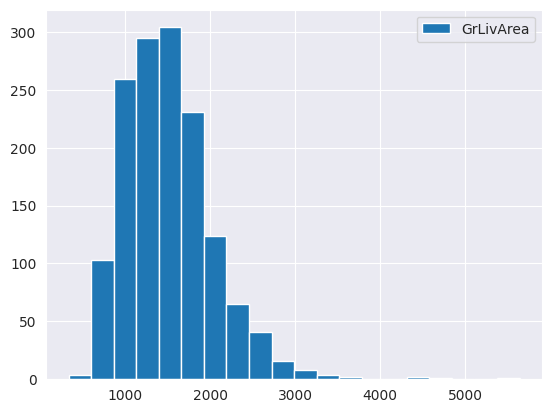

In [37]:
data.GrLivArea.hist(bins=20, label='GrLivArea')
plt.legend()
plt.show()

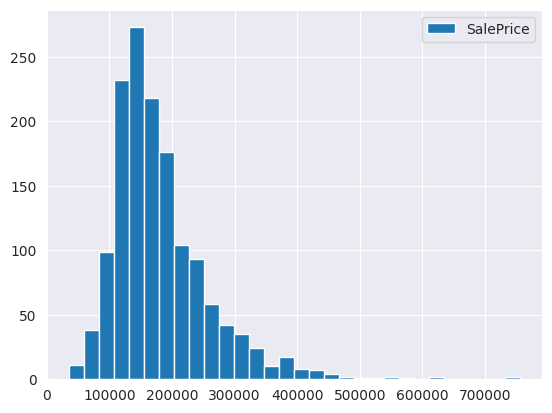

In [38]:
data.SalePrice.hist(bins=30, label='SalePrice')
plt.legend()
plt.show()

In [39]:
data.SalePrice.quantile(0.95)

np.float64(326099.9999999999)

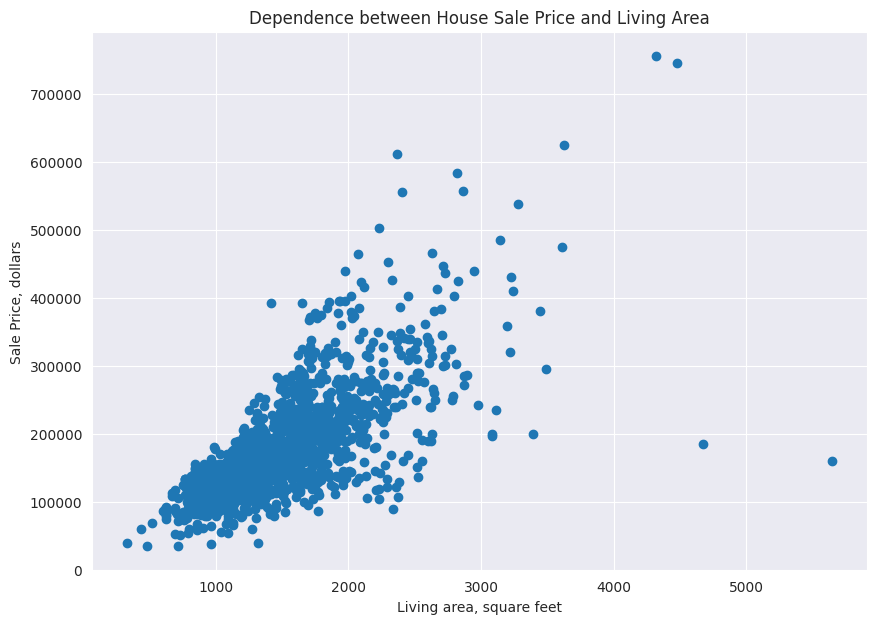

In [40]:
#set figsize of the plot
plt.figure(figsize = (10,7))
#scatter plot of the data
plt.scatter(data.GrLivArea, data.SalePrice)
#text for x axis
plt.xlabel('Living area, square feet')
#text for y axis
plt.ylabel('Sale Price, dollars')
#text for the plot title
plt.title('Dependence between House Sale Price and Living Area')
#show the plot
plt.show()

### Как смоделировать эту зависимость?

### Построение модели

* $Y$ = `SalePrice` — целевая, зависимая переменная.
* $X$ = `GrLivArea` — признак, независимая переменная.

**Модель**

Мы хотим найти прямую, отражающую зависимость цены продажи от жилой площади:

$Y = a + bX + \epsilon$.

In [41]:
X = data.GrLivArea
Y = data.SalePrice
#add the constant term to the data
X = sm.add_constant(X)
#define the model
model = sm.OLS(Y, X)
#fit the model
results = model.fit()

In [42]:
#plot the summary of our model
results.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Results: Ordinary least squares
===================================================================
Model:              OLS              Adj. R-squared:     0.502     
Dependent Variable: SalePrice        AIC:                36073.7610
Date:               2026-09-20 18:34 BIC:                36084.3334
No. Observations:   1460             Log-Likelihood:     -18035.   
Df Model:           1                F-statistic:        1471.     
Df Residuals:       1458             Prob (F-statistic): 4.52e-223 
R-squared:          0.502            Scale:              3.1442e+09
-------------------------------------------------------------------
             Coef.     Std.Err.    t    P>|t|    [0.025    0.975]  
-------------------------------------------------------------------
const      18569.0259 4480.7545  4.1442 0.0000 9779.6119 27358.4399
GrLivArea    107.1304    2.7936 38.3482 0.0000  101.6504   112.6103
-------------------------------------------------------------------
Omnibus:             261.166       Durbin-Watson:          2.025   
Prob(Omnibus):       0.000         Jarque-Bera (JB):       3432.287
Skew:                0.410         Prob(JB):               0.000   
Kurtosis:            10.467        Condition No.:          4897    
===================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors
is correctly specified.
[2] The condition number is large, 4.9e+03. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

### Что означают эти статистические показатели?

* **const** — найденное значение $a$.
* **GrLivArea** — найденное значение $b$.

Таким образом, наша модель: **$Y = 18569.0259 + 107.1304 \cdot X$**.

**Проверка гипотез и $p$-значение**

$H_0$: коэффициент равен 0 — нулевая гипотеза.

$H_1$: коэффициент не равен 0 — альтернативная гипотеза.

* Если $p$-значение $\leq \alpha$, мы **можем** отвергнуть нулевую гипотезу; коэффициент называют **значимым**.
* Если $p$-значение $> \alpha$, мы **не можем** отвергнуть нулевую гипотезу; коэффициент не признаётся статистически значимым.

**Как выбрать уровень значимости $\alpha$?**

Например, можно использовать 0,01; 0,05; 0,1.

<img src="https://drive.google.com/uc?id=1hOljO6iysu6VPtctoRjZVole2qEnTidB" width=70%>

<img src="https://drive.google.com/uc?id=1yEiawA_wtaPYIb6n1uEoV8bfw_6ZVTwx" width=70%>

Как выбрать допустимый уровень ошибок первого и второго рода?

Для проверки значимости коэффициентов часто используют $\alpha = 0{,}05$.

#### Насколько хорошо модель описывает зависимость?

**$Y = 18569.0259 + 107.1304 \cdot X$**

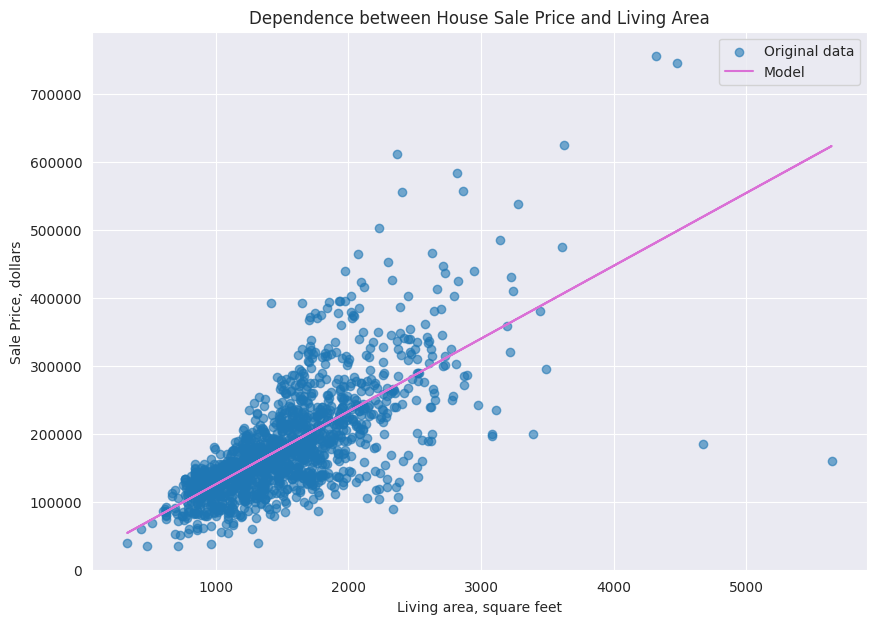

In [43]:
#set size of the plot
plt.figure(figsize = (10,7))
#scatter plot of the data
plt.scatter(data.GrLivArea, data.SalePrice, alpha=0.6, label = 'Original data')
#plot of the found regression line
plt.plot(data.GrLivArea.values, 18569.0259 + 107.1304 * data.GrLivArea.values, color = 'orchid', label='Model')
#text for x axis
plt.xlabel('Living area, square feet')
#text for y axis
plt.ylabel('Sale Price, dollars')
#text for the plot title
plt.title('Dependence between House Sale Price and Living Area')
plt.legend()
#show the plot
plt.show()

#### $R^2$ и качество регрессии

Вспомним курс статистики =)

$R^2$ — **коэффициент детерминации**, одна из самых распространённых метрик качества в задачах регрессии.

Для линейной регрессии $R^2$ определяется следующим образом:

* $y_i$ — наблюдаемое значение целевой переменной;
* $\hat{y_i}$ — предсказанное значение;
* $\overline{y} = \frac{1}{n}\sum_{i=1}^{n}y_i$ — среднее наблюдаемых значений;
* $SS_{tot} = \sum_{i}(y_i - \overline{y})^2$ — общая сумма квадратов;
* $SS_{reg} = \sum_{i}(\hat{y_i} - \overline{y})^2$ — объяснённая сумма квадратов;
* $SS_{res} = \sum_{i}(y_i - \hat{y_i})^2 = \sum_{i}residual_i^2$ — остаточная сумма квадратов.

$R^2 = \frac{SS_{reg}}{SS_{tot}} = 1 - \frac{SS_{res}}{SS_{tot}}$ — доля объяснённой вариации.

Для рассматриваемой модели $R^2$ лежит в пределах $[0, 1]$.

У нашей модели $R^2 = 0{,}502$: она объясняет примерно половину вариации целевой переменной.

**Примечание:** $R^2$ может давать смещённую оценку качества модели при добавлении признаков, поэтому стоит также смотреть на скорректированный $R^2_{adjusted}$.

### Можно ли улучшить модель?

Возьмём логарифмы $X$ и $Y$. Тогда модель примет вид **$\ln(Y) = a + b\ln(X) + \epsilon$**.

In [44]:
X = data.GrLivArea
Y = data.SalePrice
X=np.log(X)
Y=np.log(Y)
#add the constant term to the data
X = sm.add_constant(X)
#define the model
model = sm.OLS(Y, X)
#fit the model
results = model.fit()

In [45]:
#plot the summary of our model
results.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
==================================================================
Model:              OLS              Adj. R-squared:     0.533    
Dependent Variable: SalePrice        AIC:                354.1941 
Date:               2026-09-20 18:34 BIC:                364.7664 
No. Observations:   1460             Log-Likelihood:     -175.10  
Df Model:           1                F-statistic:        1666.    
Df Residuals:       1458             Prob (F-statistic): 1.60e-243
R-squared:          0.533            Scale:              0.074523 
--------------------------------------------------------------------
              Coef.    Std.Err.      t      P>|t|    [0.025   0.975]
--------------------------------------------------------------------
const         5.6681     0.1559   36.3601   0.0000   5.3623   5.9739
GrLivArea     0.8745     0.0214   40.8151   0.0000   0.8325   0.9166
------------------------------------------------------------------
Omnibus:             111.954       Durbin-Watson:          2.022  
Prob(Omnibus):       0.000         Jarque-Bera (JB):       184.755
Skew:                -0.565        Prob(JB):               0.000  
Kurtosis:            4.327         Condition No.:          162    
==================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
"""

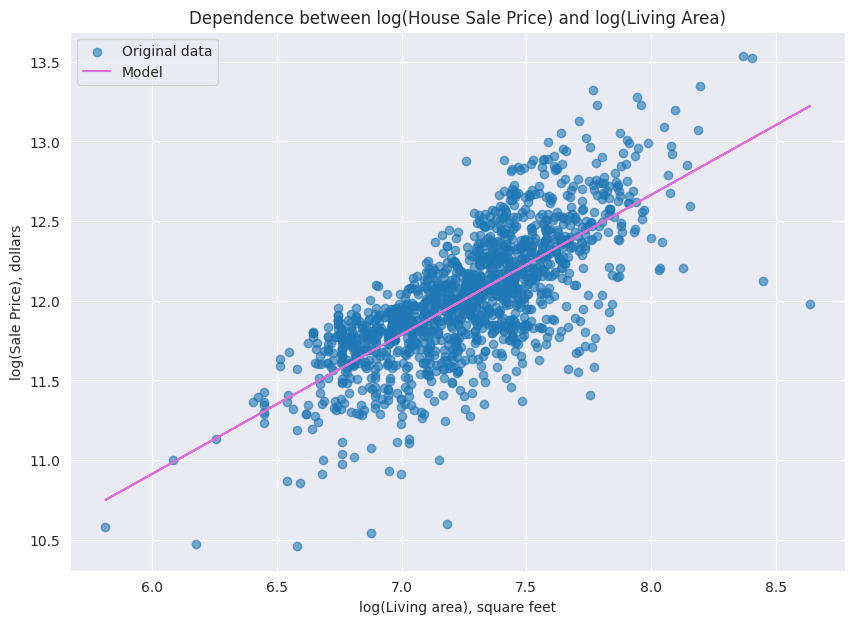

In [46]:
#set size of the plot
plt.figure(figsize = (10,7))
#scatter plot of the data
plt.scatter(np.log(data.GrLivArea), np.log(data.SalePrice), alpha=0.6, label = 'Original data')
#plot of the found regression line
plt.plot(np.log(data.GrLivArea.values), 5.6681 + 0.8745 * np.log(data.GrLivArea.values), color = 'orchid', label='Model')
#text for x axis
plt.xlabel('log(Living area), square feet')
#text for y axis
plt.ylabel('log(Sale Price), dollars')
#text for the plot title
plt.title('Dependence between log(House Sale Price) and log(Living Area)')
plt.legend()
#show the plot
plt.show()

## Множественная линейная регрессия

In [47]:
cols=['Id', 'MSSubClass', 'LotArea', 'OverallQual',\
      'OverallCond', 'YearBuilt', 'YearRemodAdd',\
      'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',\
     'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',\
     'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',\
     'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',\
     'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',\
     'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

In [48]:
data = pd.read_csv(filename, index_col=0, usecols=cols)
data.head()

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,8450,7,5,2003,2003,150,856,856,854,...,0,61,0,0,0,0,0,2,2008,208500
2,20,9600,6,8,1976,1976,284,1262,1262,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,11250,7,5,2001,2002,434,920,920,866,...,0,42,0,0,0,0,0,9,2008,223500
4,70,9550,7,5,1915,1970,540,756,961,756,...,0,35,272,0,0,0,0,2,2006,140000
5,60,14260,8,5,2000,2000,490,1145,1145,1053,...,192,84,0,0,0,0,0,12,2008,250000


Проверим наличие пропущенных значений:

In [49]:
data.isna().sum().sum()

np.int64(0)

### Зададим модель

In [50]:
X = data.drop('SalePrice', axis=1)
Y = data.SalePrice
#add the constant term to the data
X = sm.add_constant(X)
#define the model
model = sm.OLS(Y, X)
#fit the model
results = model.fit()

Вычислим некоторые статистические показатели:

In [51]:
#together with the intercept
k = X.shape[1]
#total number of observations
n = X.shape[0]
#degrees of freedom for the model:
df_model = k - 1
#degrees of freedom of the error:
df_error = n - k
print(' the number of paraters to estimate: {} \n total number of observations: {} \n degrees of freedom of the model: {} \n degrees of freedom of the errors: {}'\
      .format(k, n, df_model, df_error))

 the number of paraters to estimate: 31 
 total number of observations: 1460 
 degrees of freedom of the model: 30 
 degrees of freedom of the errors: 1429


Вычислим ранг матрицы признаков:

In [52]:
np.linalg.matrix_rank(X)

np.int64(30)

In [53]:
results.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                   OLS                  Adj. R-squared:         0.804     
Dependent Variable:      SalePrice            AIC:                    34737.9309
Date:                    2026-09-20 18:35     BIC:                    34896.5166
No. Observations:        1460                 Log-Likelihood:         -17339.   
Df Model:                29                   F-statistic:            207.6     
Df Residuals:            1430                 Prob (F-statistic):     0.00      
R-squared:               0.808                Scale:                  1.2357e+09
--------------------------------------------------------------------------------
                 Coef.      Std.Err.      t    P>|t|      [0.025       0.975]   
--------------------------------------------------------------------------------
const         608246.1995 1428003.7488  0.4259 0.6702 -2192960.6498 3409453.0488
MSSubClass      -161.5055      26.4469 -6.1068 0.0000     -213.3845    -109.6266
LotArea            0.3868       0.1016  3.8079 0.0001        0.1875       0.5860
OverallQual    18012.7658    1194.9364 15.0742 0.0000    15668.7495   20356.7821
OverallCond     4425.5378    1031.1020  4.2920 0.0000     2402.9031    6448.1725
YearBuilt        349.4880      61.2239  5.7084 0.0000      229.3896     469.5863
YearRemodAdd     140.9941      66.3557  2.1248 0.0338       10.8292     271.1590
BsmtUnfSF         -9.7412       3.1432 -3.0991 0.0020      -15.9070      -3.5754
TotalBsmtSF       20.5078       4.5849  4.4729 0.0000       11.5140      29.5016
1stFlrSF          18.9417       6.1645  3.0727 0.0022        6.8492      31.0341
2ndFlrSF          19.5079       5.7011  3.4218 0.0006        8.3244      30.6914
LowQualFinSF      -6.7807      14.8869 -0.4555 0.6488      -35.9831      22.4218
GrLivArea         31.6689       5.7075  5.5486 0.0000       20.4729      42.8650
BsmtFullBath    8400.0052    2512.7996  3.3429 0.0009     3470.8365   13329.1738
FullBath        3414.1786    2838.1391  1.2030 0.2292    -2153.1840    8981.5413
HalfBath       -1549.1048    2690.0026 -0.5759 0.5648    -6825.8793    3727.6697
BedroomAbvGr  -10546.9569    1704.6005 -6.1873 0.0000   -13890.7426   -7203.1712
KitchenAbvGr  -12589.7919    5254.5163 -2.3960 0.0167   -22897.1787   -2282.4051
TotRmsAbvGrd    5095.3485    1250.1490  4.0758 0.0000     2643.0258    7547.6713
Fireplaces      3707.1220    1784.0235  2.0780 0.0379      207.5382    7206.7058
GarageCars     10562.3784    2884.3767  3.6619 0.0003     4904.3150   16220.4418
GarageArea         2.1462       9.7916  0.2192 0.8265      -17.0613      21.3537
WoodDeckSF        25.7208       8.0357  3.2008 0.0014        9.9578      41.4838
OpenPorchSF       -6.2873      15.3029 -0.4109 0.6812      -36.3058      23.7312
EnclosedPorch      6.6916      17.0190  0.3932 0.6942      -26.6932      40.0765
3SsnPorch         21.6727      31.6870  0.6840 0.4941      -40.4854      83.8308
ScreenPorch       55.1441      17.3306  3.1819 0.0015       21.1479      89.1403
PoolArea         -42.4124      23.8035 -1.7818 0.0750      -89.1059       4.2810
MiscVal           -0.8946       1.8753 -0.4770 0.6334       -4.5731       2.7840
MoSold          -111.5227     348.4163 -0.3201 0.7490     -794.9846     571.9391
YrSold          -817.2240     709.7266 -1.1515 0.2497    -2209.4410     574.9931
--------------------------------------------------------------------------------
Omnibus:               540.774        Durbin-Watson:           1.961            
Prob(Omnibus):         0.000          Jarque-Bera (JB):        95836.983        
Skew:                  -0.553         Prob(JB):                0.000            
Kurtosis:              42.676         Condition No.:           13129423541445026
================================================================================
Notes:


**Пояснение результатов:**

* $R^2 = 0{,}808$;
* $R^2_{adj} = 0{,}804$;
* Log-Likelihood = −1733 — значение логарифма функции правдоподобия в оптимуме;
* AIC = 34738 — информационный критерий Акаике для выбора модели; предпочтительна модель с наименьшим AIC;
* BIC = 34897 — байесовский информационный критерий, используемый для той же цели;
* F-statistic = 208.

**F-критерий общей значимости модели:**

$H_{0}$: модель только со свободным членом описывает данные не хуже текущей модели; остальные признаки вместе не дают улучшения.

$H_{1}$: текущая модель описывает данные значимо лучше модели только со свободным членом; дополнительные признаки улучшают модель.

$F = \frac{R^2/(k-1)}{(1-R^2)/(n-k)}$,

где $k$ — число параметров с учётом свободного члена, $n$ — число наблюдений.

Если рассчитанное значение $F$ больше критического значения из статистической таблицы, нулевую гипотезу можно отвергнуть.

* Prob(F-statistic) = 0,0 — $p$-значение F-критерия;
* Df model — число степеней свободы модели;
* Df Residuals — число степеней свободы остатков.

**Примечание:** значения Df могут отличаться от ожидаемых. В используемой реализации OLS число степеней свободы модели вычисляется через ранг матрицы $X$, который здесь равен 29.

* Scale — оценка дисперсии остатков регрессии;
* Durbin-Watson = 1,96 — статистика для проверки автокорреляции остатков. Она лежит в пределах от 0 до 4: значения существенно меньше 2 указывают на положительную, а существенно больше 2 — на отрицательную автокорреляцию.

**Примечание:** не все признаки статистически значимы. Что делать дальше? Есть несколько способов отбора признаков:

* **Исключение по $p$-значению.** Построить модель со всеми признаками, а затем последовательно исключать незначимые признаки, начиная с признака с наибольшим $p$-значением.

* **Прямой отбор.** Построить модели с каждым отдельным признаком и выбрать лучшую. Затем добавить к нему по очереди второй признак и снова выбрать лучшую модель. Продолжать добавлять признаки по одному, пока качество не перестанет улучшаться.

* **Обратный отбор.** Построить модель со всеми признаками и затем удалять их по одному, выбирая удаление, которое даёт наибольшее улучшение. Остановиться, когда дальнейшее удаление начнёт ухудшать качество модели.

### Задание 1

Найдите коллинеарные признаки и оставьте только один из каждой группы.

In [ ]:
# ваш код здесь

### Задание 2: реализуйте исключение признаков по $p$-значению

**Подсказки:**

* используйте циклы;
* смотрите на показатели качества (помните, что $R^2$ зависит от числа признаков) и $p$-значения соответствующих коэффициентов;
* включите свободный член.

**Примечание:** незначимый признак в одной модели может стать значимым в другой, и наоборот.

**Примечание 2:** модели, обученные с разными наборами признаков, — разные модели.

In [ ]:
# ваш код здесь

## Множественная регрессия в sklearn

* [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) — «классическая» линейная регрессия с минимизацией MSE. Аналитическое решение: $w^* = (X^TX)^{-1}X^Ty$.
* [`Ridge`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) — линейная регрессия с минимизацией MSE и $\ell_2$-регуляризацией.
* [`Lasso`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) — линейная регрессия с минимизацией MSE и $\ell_1$-регуляризацией.

## Регуляризация

* Добавим требование, чтобы значение регуляризатора $R(\beta)$ было небольшим:

$$
\sum_{n=1}^{N}\left(x_{n}^{T}\beta-y_{n}\right)^{2}+\lambda R(\beta)\to\min_{\beta}.
$$

* $\lambda>0$ — гиперпараметр.
* $R(\beta)$ штрафует модель за сложность:

$$
\begin{array}{ll}
R(\beta)=||\beta||_{1} & \text{(L1) регрессия Lasso}\\
R(\beta)=||\beta||_{2}^{2} & \text{(L2) регрессия Ridge}
\end{array}
$$

<img src="https://drive.google.com/uc?id=1WIONg5WAtiV4jKjmOA2Zn_B4uPAVPp6y" width=70%>

Для решения важна как **точность**, так и **простота модели**. Параметр $\lambda$ управляет сложностью: при увеличении $\lambda$ модель обычно становится проще.

### Виды регуляризации: Ridge

Ridge-регрессия минимизирует функцию

$$\Large J(X, y, \beta) = \mathcal{L} + \lambda \sum_j\beta_j^2,$$

где $\mathcal{L}$ — сумма квадратов ошибок по всему набору данных, а $\lambda \sum_j\beta_j^2$ — штраф $\ell_2$.

Параметр $\lambda \geq 0$ подбирают отдельно. Как и метод наименьших квадратов, Ridge стремится уменьшить сумму квадратов остатков. Но штраф за большие коэффициенты сдвигает оценки $\beta_j$ к нулю. При $\lambda = 0$ штраф не действует, и Ridge даёт оценки метода наименьших квадратов. Чем больше $\lambda$, тем сильнее влияние штрафа и тем ближе коэффициенты к нулю.

### Виды регуляризации: Lasso

У Ridge есть ограничение: этот метод не отбирает признаки. Все предикторы остаются в итоговой модели. Штраф уменьшает коэффициенты, но обычно не делает их точно равными нулю. При большом числе признаков это затрудняет интерпретацию модели.

Lasso — альтернатива Ridge, которая минимизирует функцию

$$\Large J(X, y, \beta) = \mathcal{L} + \lambda \sum_j|\beta_j|,$$

где $\mathcal{L}$ — сумма квадратов ошибок по всему набору данных, а $\lambda \sum_j|\beta_j|$ — штраф $\ell_1$.

Формулы Ridge и Lasso похожи: в Lasso квадрат коэффициента в штрафе заменён его модулем. Оба метода уменьшают коэффициенты, но при достаточно большом $\lambda$ Lasso может сделать некоторые из них точно равными нулю и тем самым отобрать признаки.

In [54]:
data.head()

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,8450,7,5,2003,2003,150,856,856,854,...,0,61,0,0,0,0,0,2,2008,208500
2,20,9600,6,8,1976,1976,284,1262,1262,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,11250,7,5,2001,2002,434,920,920,866,...,0,42,0,0,0,0,0,9,2008,223500
4,70,9550,7,5,1915,1970,540,756,961,756,...,0,35,272,0,0,0,0,2,2006,140000
5,60,14260,8,5,2000,2000,490,1145,1145,1053,...,192,84,0,0,0,0,0,12,2008,250000


#### Регуляризация L2

In [55]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop('SalePrice', axis=1), data.SalePrice, \
                                                    test_size=0.33, random_state=42)

model = Ridge()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

print("Test MSE = %.4f" % mean_squared_error(y_test, y_pred))
print("Train MSE = %.4f" % mean_squared_error(y_train, y_train_pred))

Test MSE = 1614154736.5663
Train MSE = 1118176485.6748


### Кросс-валидация

<img src="https://docs.splunk.com/images/thumb/e/ee/Kfold_cv_diagram.png/1200px-Kfold_cv_diagram.png" width=50%>

In [56]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print("Cross validation scores:\n\t", "\n\t".join("%.4f" % -x for x in cv_scores))
print("Mean CV MSE = %.4f" % np.mean(-cv_scores))

Cross validation scores:
	 1479384499.2952
	2503090058.5411
	1201178649.8985
	694202047.1882
	2348370475.1935
Mean CV MSE = 1645245146.0233


In [57]:
def show_weights(features, weights, scales):
    fig, axs = plt.subplots(figsize=(14, 10), ncols=2)
    sorted_weights = sorted(zip(weights, features, scales), reverse=True)
    weights = [x[0] for x in sorted_weights]
    features = [x[1] for x in sorted_weights]
    scales = [x[2] for x in sorted_weights]
    sns.barplot(y=features, x=weights, ax=axs[0])
    axs[0].set_xlabel("Weight")
    sns.barplot(y=features, x=scales, ax=axs[1])
    axs[1].set_xlabel("Scale")
    plt.tight_layout()

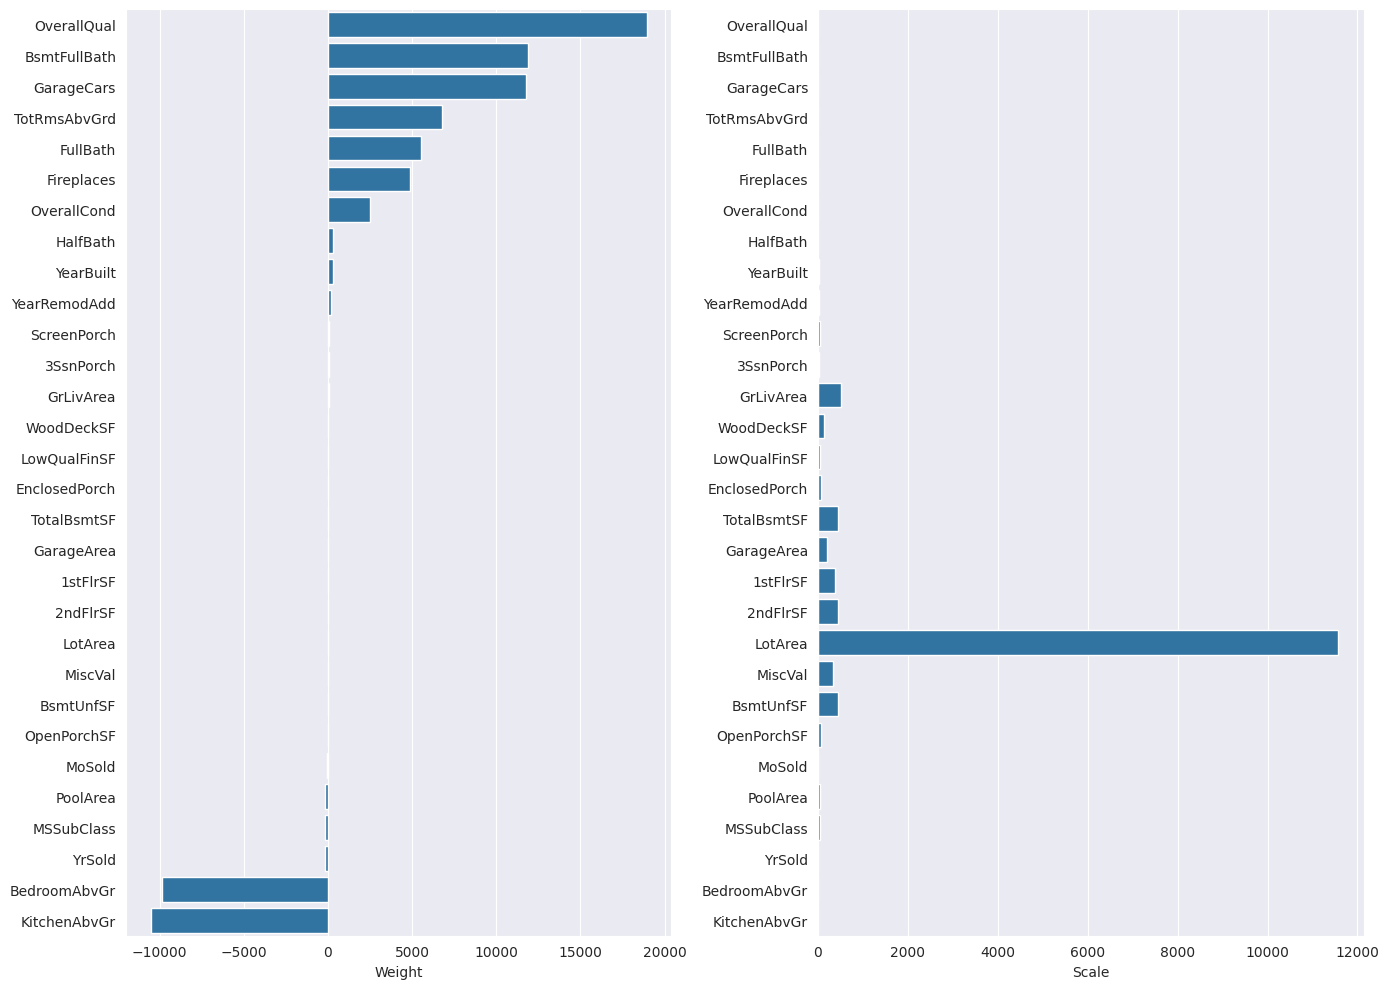

In [58]:
show_weights(X_train.columns, model.coef_, X_train.std())

### Преобразование признаков

[`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Ridge()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_train_pred = model.predict(X_train_scaled)

print("Test MSE = %.4f" % mean_squared_error(y_test, y_pred))
print("Train MSE = %.4f" % mean_squared_error(y_train, y_train_pred))

Test MSE = 1614337582.6718
Train MSE = 1118171436.8603


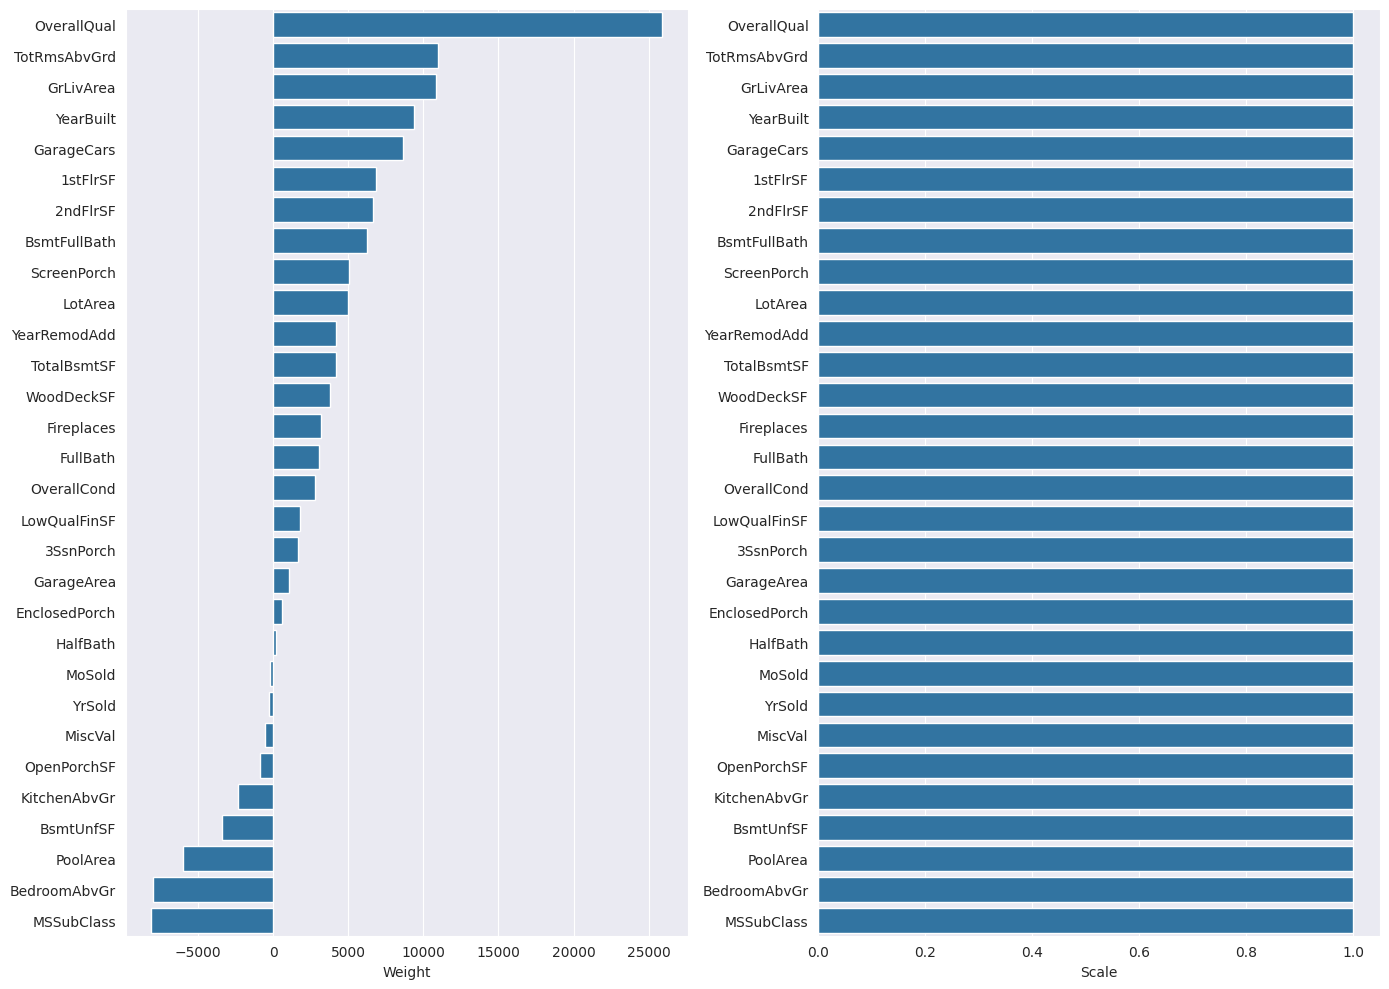

In [60]:
scales = pd.Series(data=X_train_scaled.std(axis=0), index=X_train.columns)
show_weights(X_train.columns, model.coef_, scales)

### Поиск по сетке (GridSearch)

Best alpha = 297.6351


Text(0, 0.5, 'CV score')

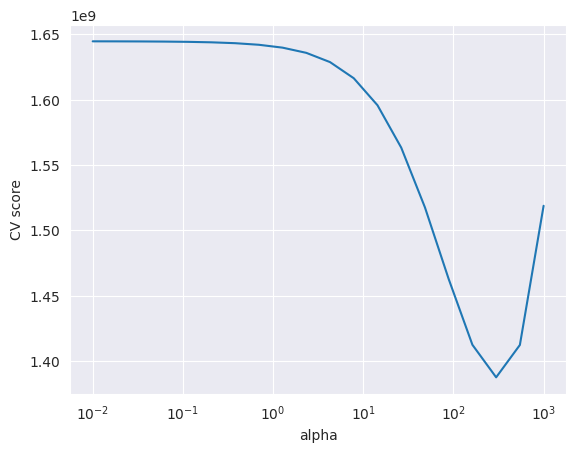

In [61]:
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-2, 3, 20)
searcher = GridSearchCV(Ridge(), [{"alpha": alphas}], scoring="neg_mean_squared_error", cv=5)
searcher.fit(X_train_scaled, y_train)

best_alpha = searcher.best_params_["alpha"]
print("Best alpha = %.4f" % best_alpha)

plt.plot(alphas, -searcher.cv_results_["mean_test_score"])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV score")

**Вопрос:** почему мы не подбираем коэффициент регуляризации на обучающей или тестовой выборке?

### Регуляризация L1

In [62]:
from sklearn.linear_model import Lasso

model = Lasso().fit(X_train, y_train)
y_pred = model.predict(X_test)
print("RMSE = %.4f" % mean_squared_error(y_test, y_pred))

RMSE = 1614473738.4383


#### Распределение остатков

<Axes: xlabel='SalePrice', ylabel='Density'>

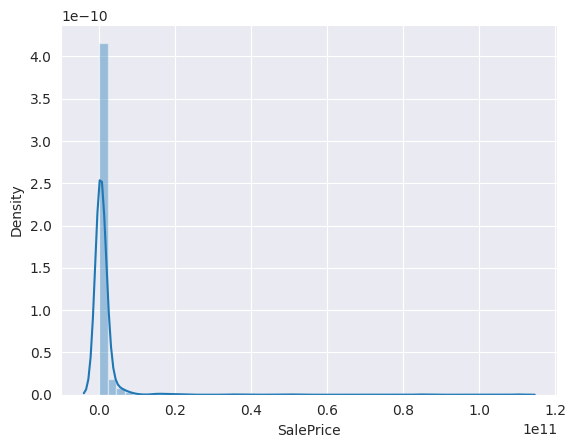

In [63]:
error = (y_train - model.predict(X_train)) ** 2
sns.distplot(error)

Есть объекты с большими остатками. Удалим их из обучающей выборки: например, объекты с остатками выше 95-го процентиля.

In [64]:
mask = (error < np.quantile(error, 0.95))

In [65]:
model = Lasso().fit(X_train[mask], y_train[mask])
y_pred = model.predict(X_test)
print("Test RMSE = %.4f" % mean_squared_error(y_test, y_pred))

Test RMSE = 1367074818.1835


In [66]:
X_train = X_train[mask]
y_train = y_train[mask]

<Axes: xlabel='SalePrice', ylabel='Density'>

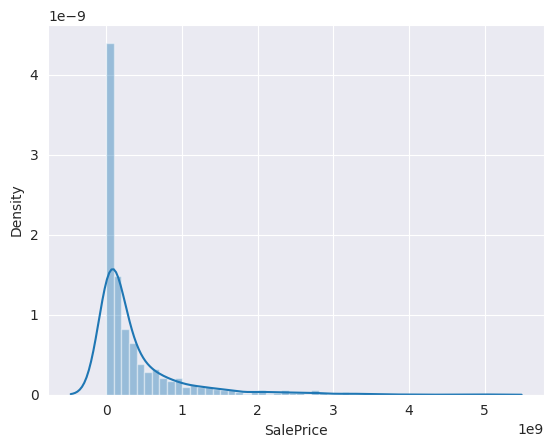

In [67]:
error = (y_train[mask] - model.predict(X_train[mask])) ** 2
sns.distplot(error)